---

# **Homework 6**

**Course:** CSCE-636-700

**Instructor:** Dr. Anxiao Jiang

**Author:** Brody Jordan (431005357)

---

## Assignment details

Check out the Jupyter notebook for Chapter 13 at https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter13_timeseries-forecasting.ipynb . It has tried 6 methods for the temperature prediction problem: Try 1 (A common-sense, non-machine learning baseline method), Try 2 (A fully connected neural network), Try 3 (1-d convolutional neural networks), Try 4 (LSTM with recurrent dropout), Try 5 (stacking RNN layers), Try 6 (Bidirectional RNN).

Your task: use the above 6 methods to predict the temperature in 48 hours (instead of 24 hours). In the Jupyter notebook, include your code as well as the performance of the 6 methods.  

---


In [73]:
!pip install keras keras-hub --upgrade -q

In [74]:
import os
os.environ["KERAS_BACKEND"] = "jax"

---

## Data preparation

In [75]:
!wget -q https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip -o jena_climate_2009_2016.csv.zip

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [76]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [77]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

Text(0.5, 1.0, 'Temperature over all days')

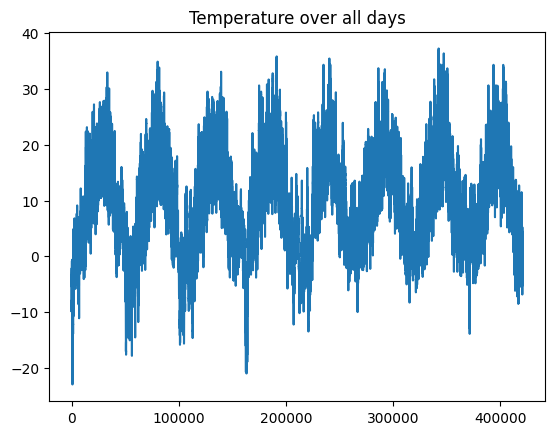

In [78]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)
plt.title("Temperature over all days")

Text(0.5, 1.0, 'Temperature over the first 10 days')

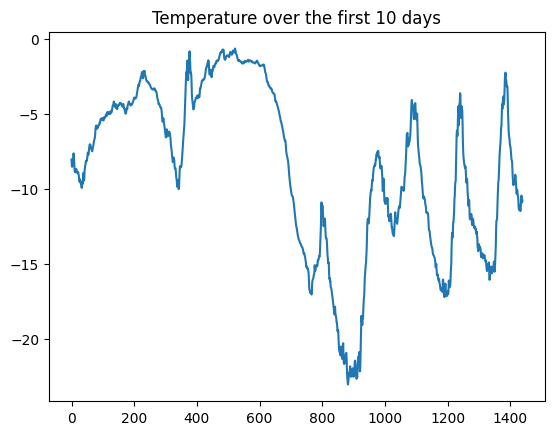

In [79]:
plt.plot(range(1440), temperature[:1440])
plt.title("Temperature over the first 10 days")

In [80]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [81]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

<a id='hour_offset'></a> Here I changed the `hour_offset` variable from 24 to 48 hours to make predictions further out.


In [82]:
import numpy as np
import keras

# 24 originally, now 48
hour_offset = 48

sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + hour_offset - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [83]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


In [84]:
import matplotlib.pyplot as plt

def plot_train_val_mae(history):
    loss = history.history["mae"]
    val_loss = history.history["val_mae"]
    epochs = range(1, len(loss) + 1)
    plt.figure()
    plt.plot(epochs, loss, "r--", label="Training MAE")
    plt.plot(epochs, val_loss, "b", label="Validation MAE")
    plt.title("Training and validation MAE")
    plt.legend()
    plt.show()

---

## Prediction Methods


### 1. Non-machine-learning

In [85]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 3.21
Test MAE: 3.47


### 2. Fully connected NN

In [86]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 17.5162 - mae: 3.2675 - val_loss: 15.9966 - val_mae: 3.1763
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 11.9776 - mae: 2.7473 - val_loss: 16.5549 - val_mae: 3.2065
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 10.9421 - mae: 2.6224 - val_loss: 17.8248 - val_mae: 3.3171
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 10.3252 - mae: 2.5444 - val_loss: 18.4595 - val_mae: 3.3801
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 9.9658 - mae: 2.4983 - val_loss: 19.5348 - val_mae: 3.4681
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 9.6415 - mae: 2.4569 - val_loss: 19.5525 - val_mae: 3.4705
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 9.3646 - mae: 2.4207 - val_loss: 19.2921 - val_mae: 3.4341
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 9.1993 - mae: 2.4016 - val_loss: 19.4145 - val_mae: 3.4506
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7

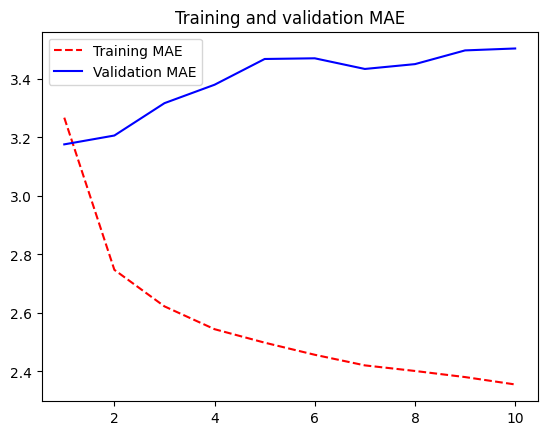

In [87]:
plot_train_val_mae(history)

### 3. 1-d CNN

In [88]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 26.7886 - mae: 4.0449 - val_loss: 20.4657 - val_mae: 3.5523
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 17.5510 - mae: 3.3488 - val_loss: 19.2948 - val_mae: 3.4892
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 15.6932 - mae: 3.1579 - val_loss: 20.4298 - val_mae: 3.5977
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.4900 - mae: 3.0241 - val_loss: 21.0778 - val_mae: 3.6516
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 13.5764 - mae: 2.9244 - val_loss: 22.8203 - val_mae: 3.8127
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 12.7621 - mae: 2.8364 - val_loss: 22.9325 - val_mae: 3.7795
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 12.1692 - mae: 2.7696 - val_loss: 23.7681 - val_mae: 3.8701
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 11.7488 - mae: 2.7223 - val_loss: 23.4498 - val_mae: 3.8082
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 

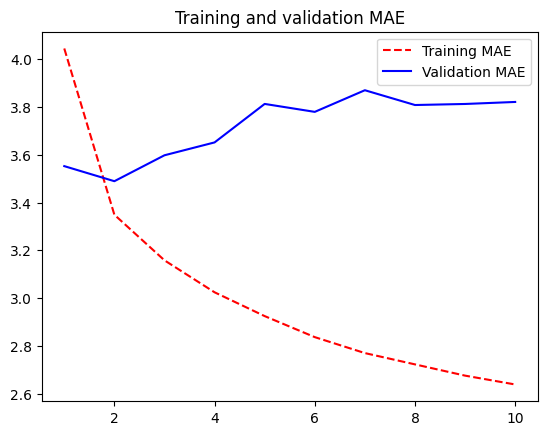

In [89]:
plot_train_val_mae(history)

### 4. LSTM with recurrent dropout

In [90]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 37.5417 - mae: 4.6414 - val_loss: 16.3996 - val_mae: 3.1476
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 21.8821 - mae: 3.6696 - val_loss: 14.9090 - val_mae: 3.0071
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 20.2529 - mae: 3.5294 - val_loss: 14.5193 - val_mae: 2.9816
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 19.4487 - mae: 3.4569 - val_loss: 14.7918 - val_mae: 3.0071
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 18.7042 - mae: 3.3894 - val_loss: 14.9270 - val_mae: 3.0205
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 18.1969 - mae: 3.3386 - val_loss: 14.6787 - val_mae: 2.9991
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 17.7527 - mae: 3.2923 - val_loss: 14.8449 - val_mae: 3.0076
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 17.2655 - mae: 3.2459 - val_loss: 14.8341 - val_mae: 3.0051
Epoch 9/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 

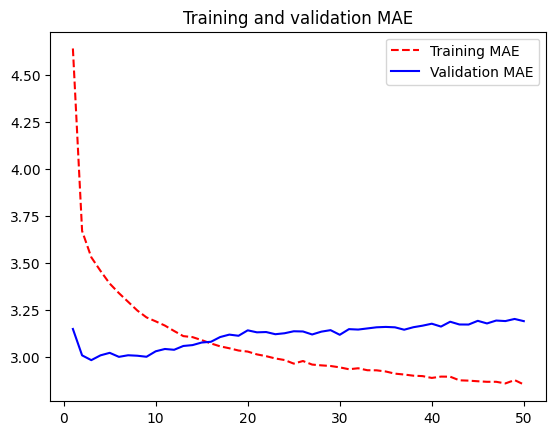

In [91]:
plot_train_val_mae(history)

### 5. Stacking RNN layers

In [92]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 35.1411 - mae: 4.4848 - val_loss: 16.1265 - val_mae: 3.1022
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 20.6898 - mae: 3.5615 - val_loss: 14.6987 - val_mae: 2.9935
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 19.2829 - mae: 3.4350 - val_loss: 14.2396 - val_mae: 2.9613
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 18.2352 - mae: 3.3474 - val_loss: 14.1476 - val_mae: 2.9562
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 17.6277 - mae: 3.2887 - val_loss: 14.2891 - val_mae: 2.9832
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 16.9746 - mae: 3.2251 - val_loss: 14.8904 - val_mae: 3.0217
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 16.4005 - mae: 3.1701 - val_loss: 14.6013 - val_mae: 2.9924
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 15.8666 - mae: 3.1197 - val_loss: 14.8138 - val_mae: 3.0191
Epoch 9/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 

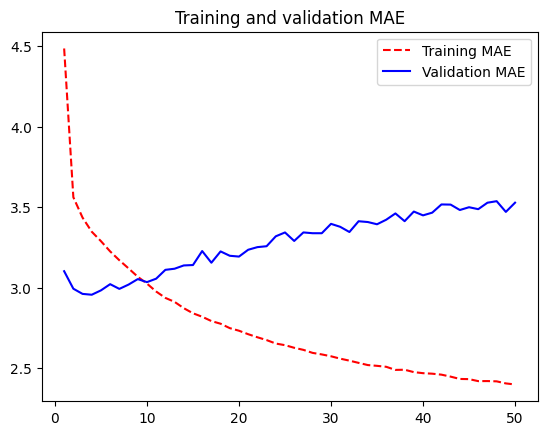

In [93]:
plot_train_val_mae(history)

### 6. Bidirectional RNN

In [94]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 35.6532 - mae: 4.4210 - val_loss: 17.3604 - val_mae: 3.2649
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 16.2262 - mae: 3.1774 - val_loss: 16.3552 - val_mae: 3.1850
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 15.2079 - mae: 3.0863 - val_loss: 16.6454 - val_mae: 3.2127
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 14.3915 - mae: 2.9994 - val_loss: 16.2449 - val_mae: 3.1570
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 13.4530 - mae: 2.8952 - val_loss: 16.1623 - val_mae: 3.1681
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 13.0668 - mae: 2.8432 - val_loss: 16.2193 - val_mae: 3.1502
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 12.2503 - mae: 2.7579 - val_loss: 17.0176 - val_mae: 3.2103
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 11.6147 - mae: 2.6864 - val_loss: 16.8522 - val_mae: 3.2299
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 

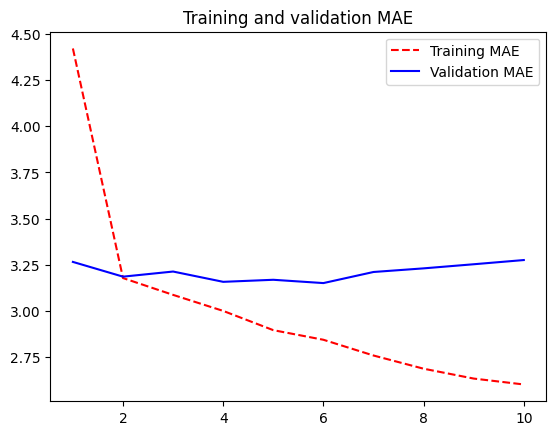

In [95]:
plot_train_val_mae(history)

---

## Results

I first ran the models with the default 24-hour prediction to collect the training, validation, and test results for comparison. I then raised the temperature prediction to 48 hours (current configuration, see § Data preparation) and recollected the test MAE values. I have tabulated the results here: <br/><br/>

\begin{array}{|l|l|l|}
\hline
\textbf{Prediction method} & \textbf{24-hour test MAE} & \textbf{48-hour test MAE} \\
\hline
\text{Non-machine-learning}      & 2.62 & 3.47 \\
\text{Fully connected NN}        & 2.64 & 3.31 \\
\text{1-d CNN}                   & 3.22 & 3.66 \\
\text{LSTM w/ recurrent dropout} & 2.53 & 3.28 \\
\text{Stacking RNN layers}       & \mathbf{2.41} & \mathbf{3.20} \\
\text{Bidirectional RNN}         & 2.59 & 3.46 \\
\hline
\end{array}

<br/><br/>
As you can see from the table, stacking RNN layers yielded the lowest MAE for both the 24-hour prediction and the 48-hour prediction.

Additionally, MAE increased universally as the prediction window shifted forward. This is not surprising as temperatures are more likely to shift over 48 hours compared to the shift over 24 hours, making it harder to predict accurately.

All of the training and validation figures for the 48-hour prediction are shown above in this notebook.

---
